# 01 — Exploratory Data Analysis: Bank Marketing Dataset

Analyzes the UCI Bank Marketing dataset (`data/kaggle/bank-additional-full.csv`) to understand feature distributions, class imbalance, and correlations before designing bandit arm features.

**Dataset:** 41,188 rows × 21 features (Portuguese bank direct marketing campaigns, 2008–2010)  
**Target:** `y` — did the client subscribe to a term deposit? (yes/no)

In [1]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)

DATA_PATH = ROOT / "data" / "kaggle" / "bank_marketing_dataset" / "bank-additional-full.csv"
print(f"Dataset path: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")

Dataset path: /Volumes/zeus/project/project_persona/git-portfolio/postech-fiap-ml-tech-challege-5-datathon/data/kaggle/bank_marketing_dataset/bank-additional-full.csv
Exists: True


In [2]:
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Schema Overview

In [3]:
print(df.dtypes.to_string())
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\n'unknown' counts per column:")
for col in df.select_dtypes(include="object").columns:
    n = (df[col] == "unknown").sum()
    if n > 0:
        print(f"  {col}: {n} ({n/len(df):.1%})")

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object

Missing values:
Series([], dtype: int64)

'unknown' counts per column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


## 2. Target Distribution (Class Imbalance)

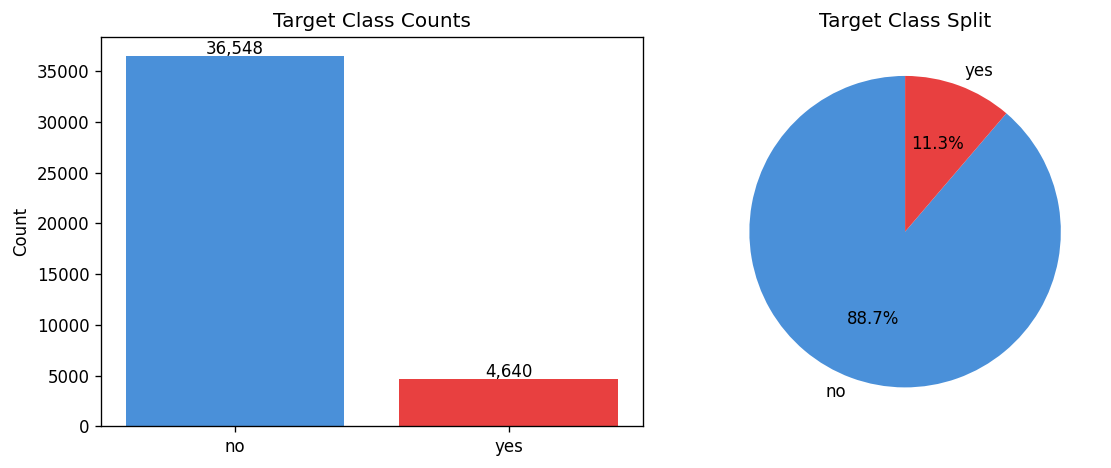

Imbalance ratio: 7.9:1 (no:yes)


In [4]:
counts = df["y"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(counts.index, counts.values, color=["#4A90D9", "#E84040"])
axes[0].set_title("Target Class Counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=["#4A90D9", "#E84040"], startangle=90)
axes[1].set_title("Target Class Split")

plt.tight_layout()
plt.show()
print(f"Imbalance ratio: {counts['no']/counts['yes']:.1f}:1 (no:yes)")

## 3. Numeric Feature Distributions

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
df[numeric_cols].describe().T.round(2)

Numeric features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


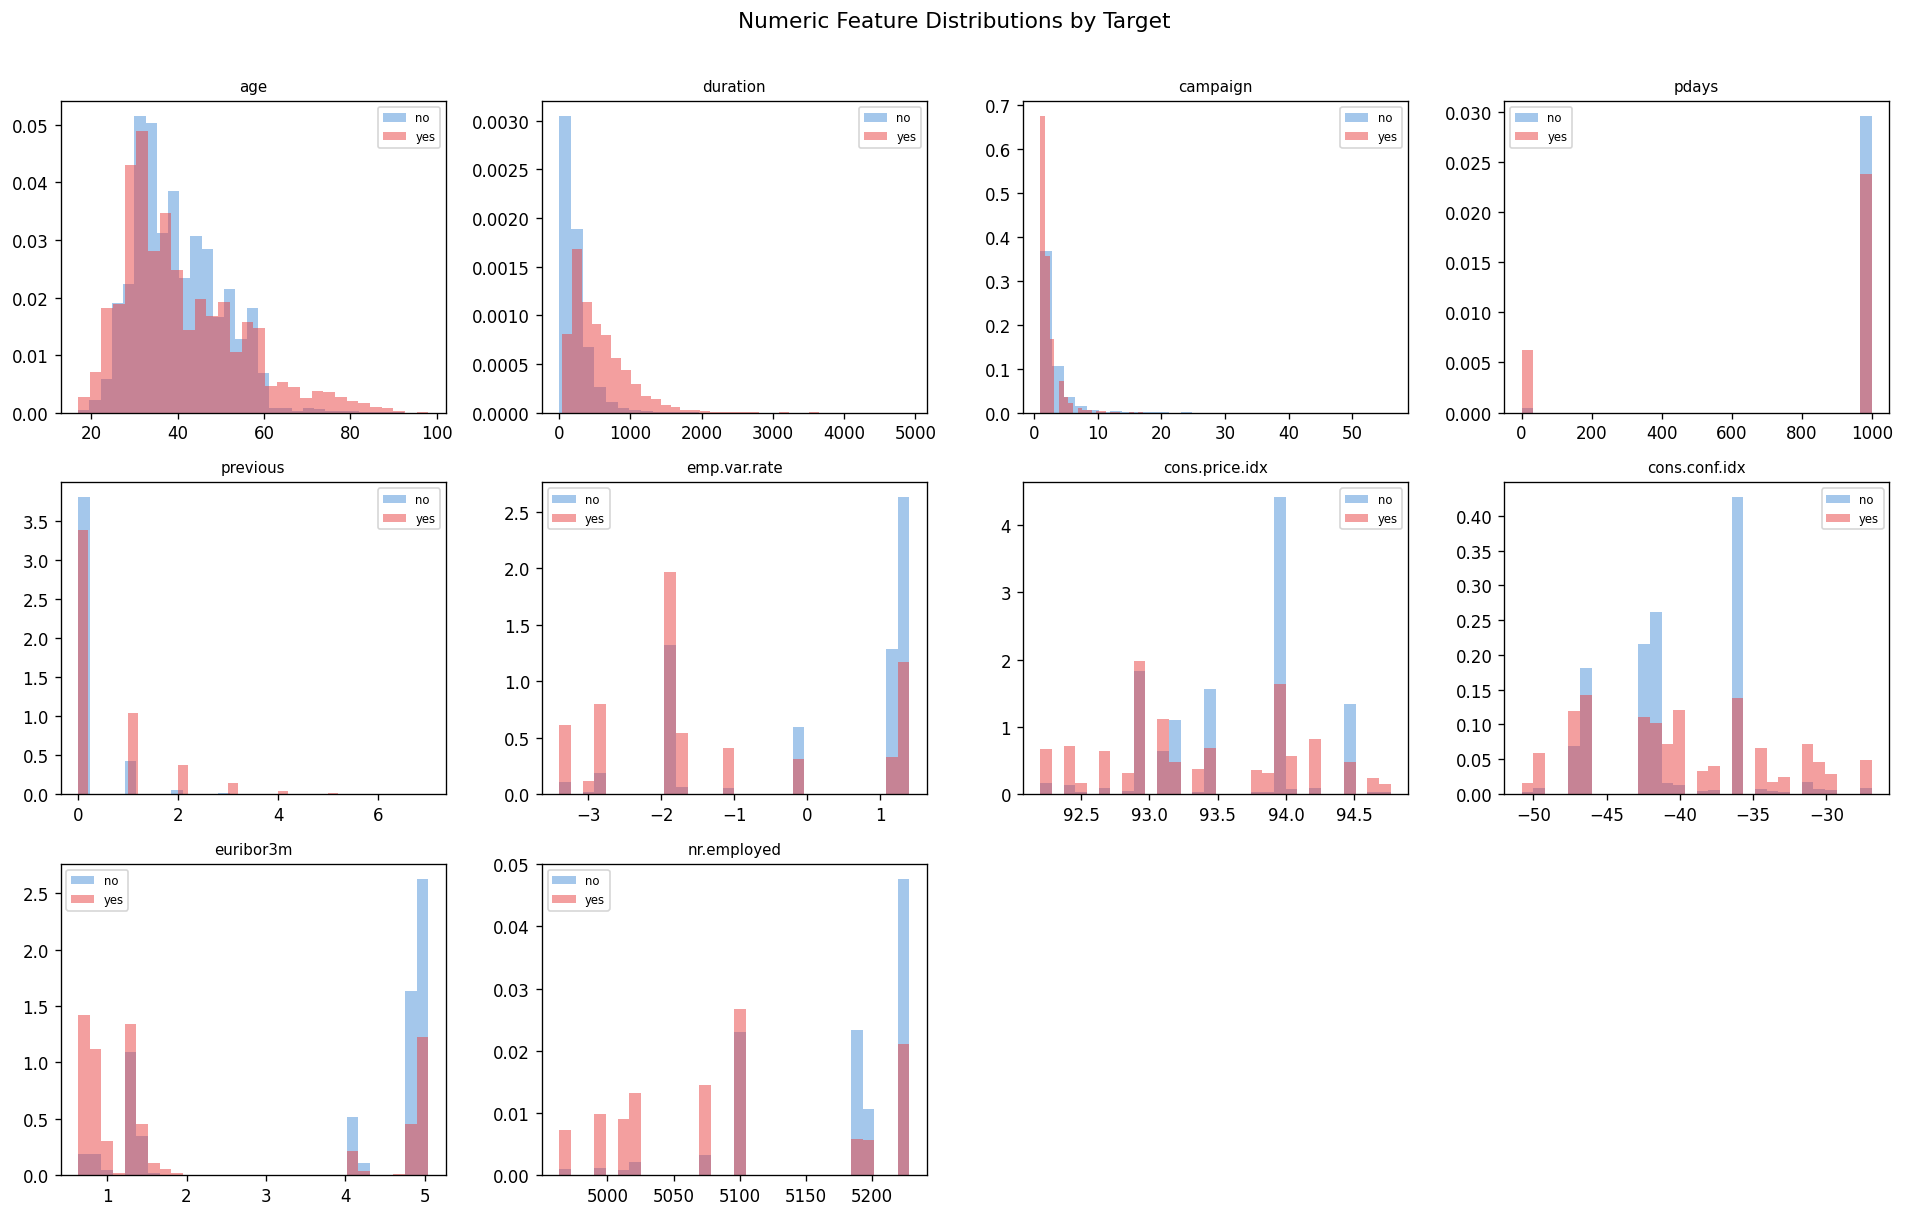

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for val, color in [("no", "#4A90D9"), ("yes", "#E84040")]:
        axes[i].hist(df.loc[df["y"] == val, col].dropna(),
                     bins=30, alpha=0.5, color=color, label=val, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions by Target", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

In [7]:
cat_cols = df.select_dtypes(include="object").columns.drop("y").tolist()
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


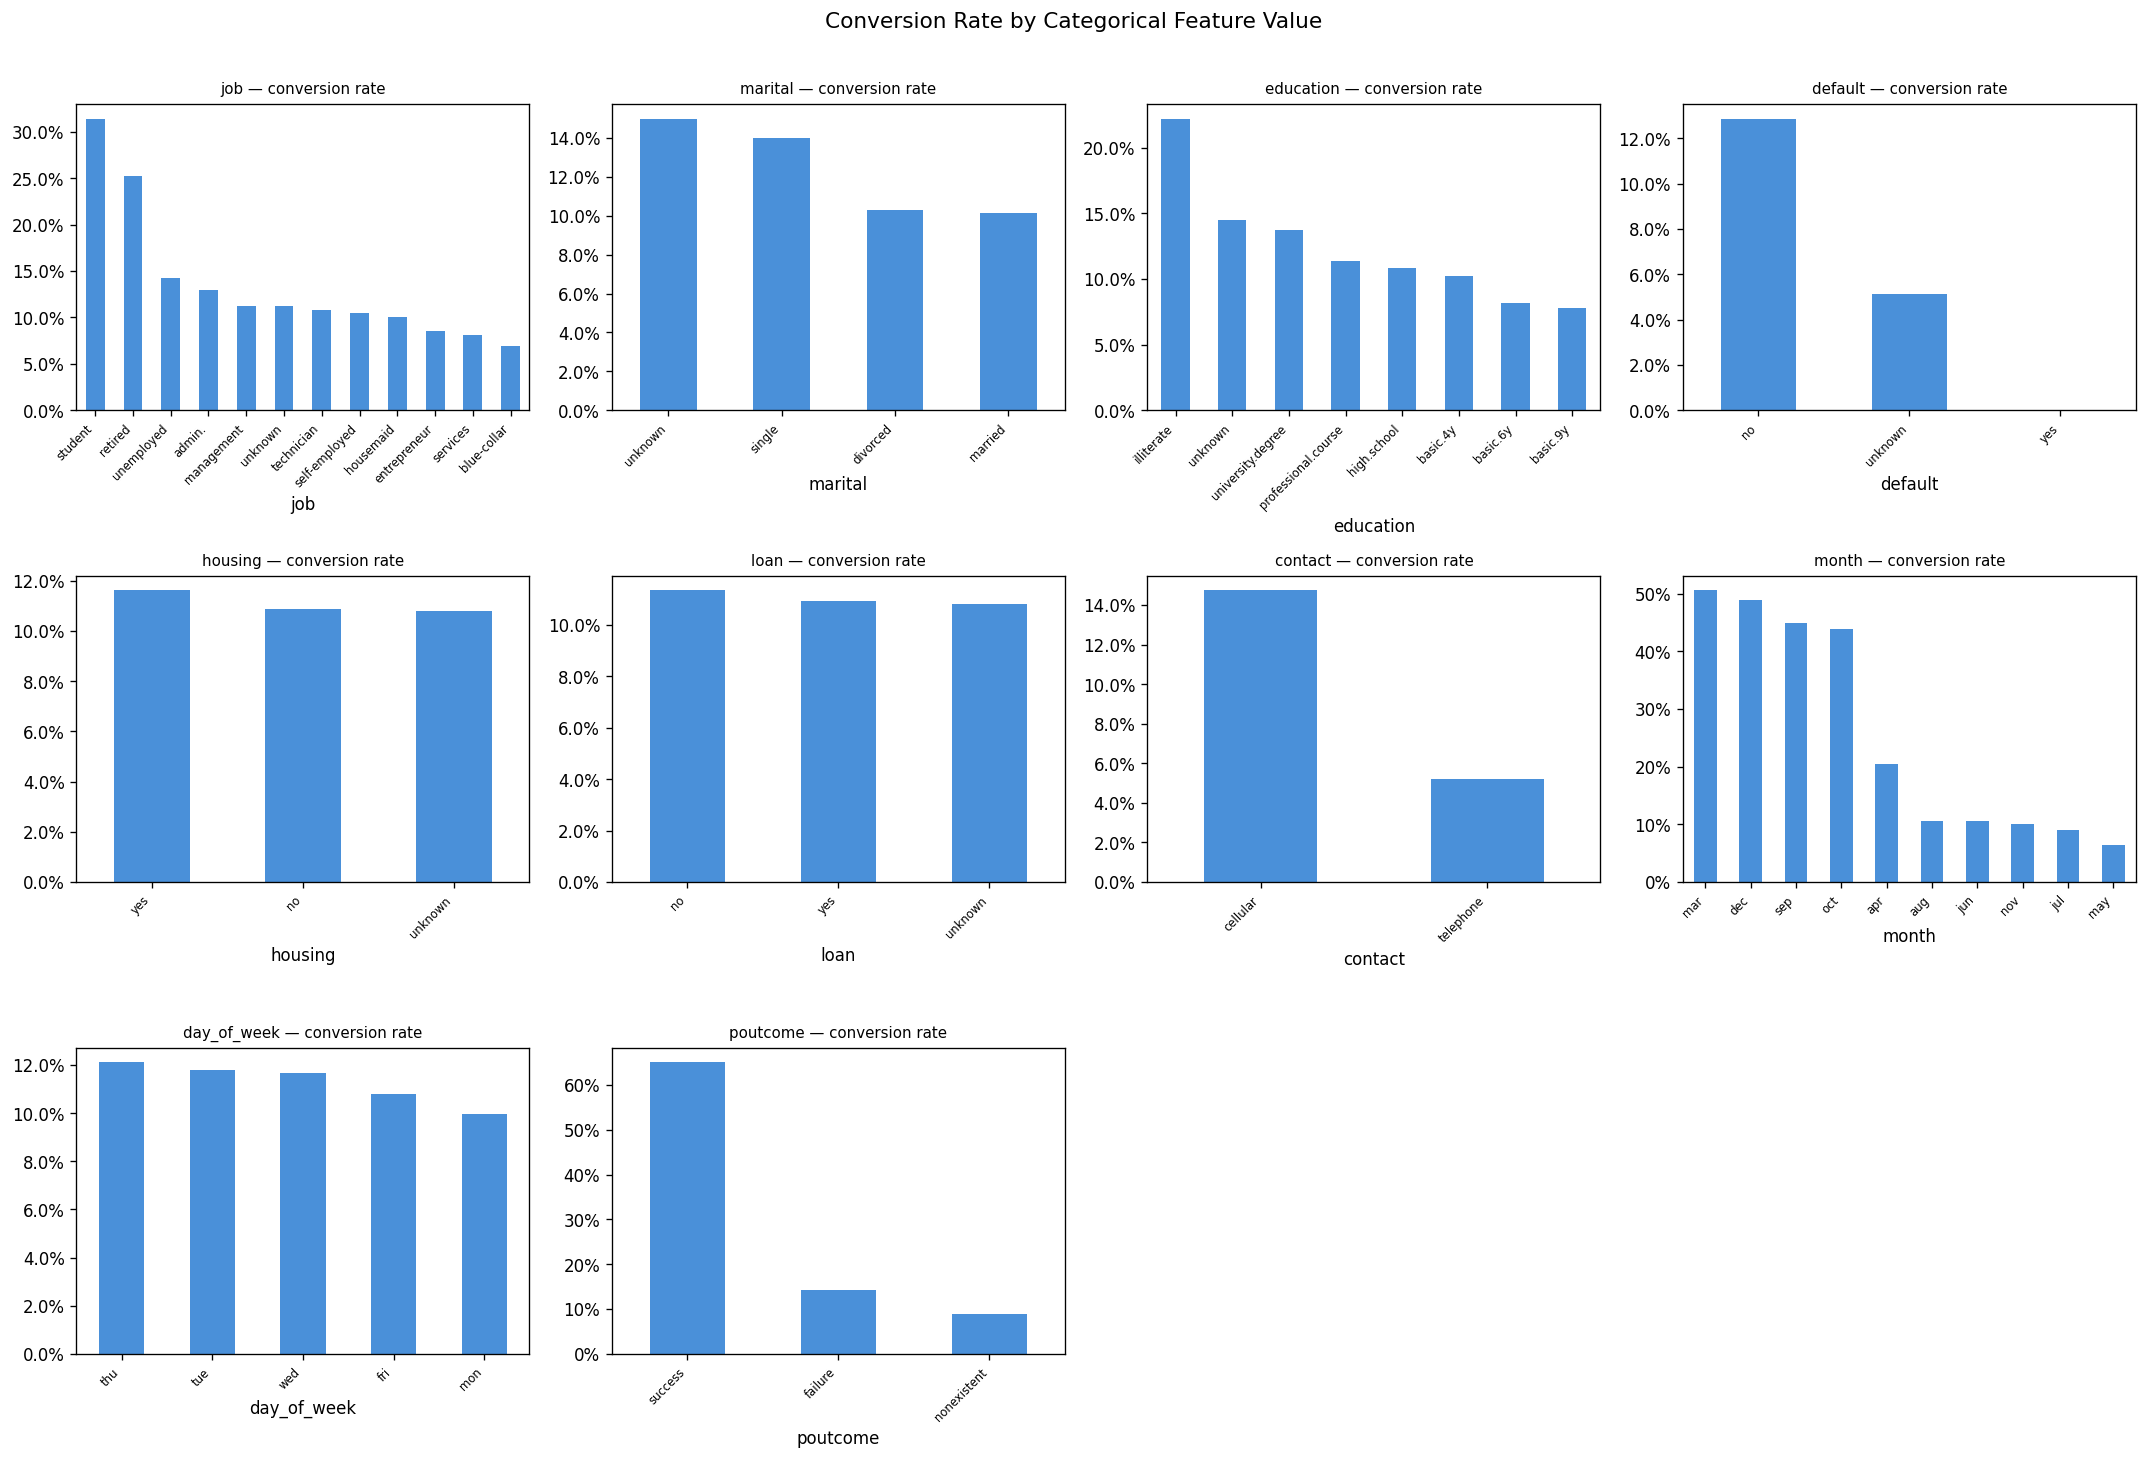

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    conv_rate = df.groupby(col)["y"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
    conv_rate.plot(kind="bar", ax=axes[i], color="#4A90D9")
    axes[i].set_title(f"{col} — conversion rate", fontsize=9)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right", fontsize=7)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Conversion Rate by Categorical Feature Value", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Age Distribution and Segment Analysis

/var/folders/ky/st2sc9nj7bv1rt3m2r68b1t40000gn/T/ipykernel_40127/239132690.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby(["age_band", "education"])["y"].apply(


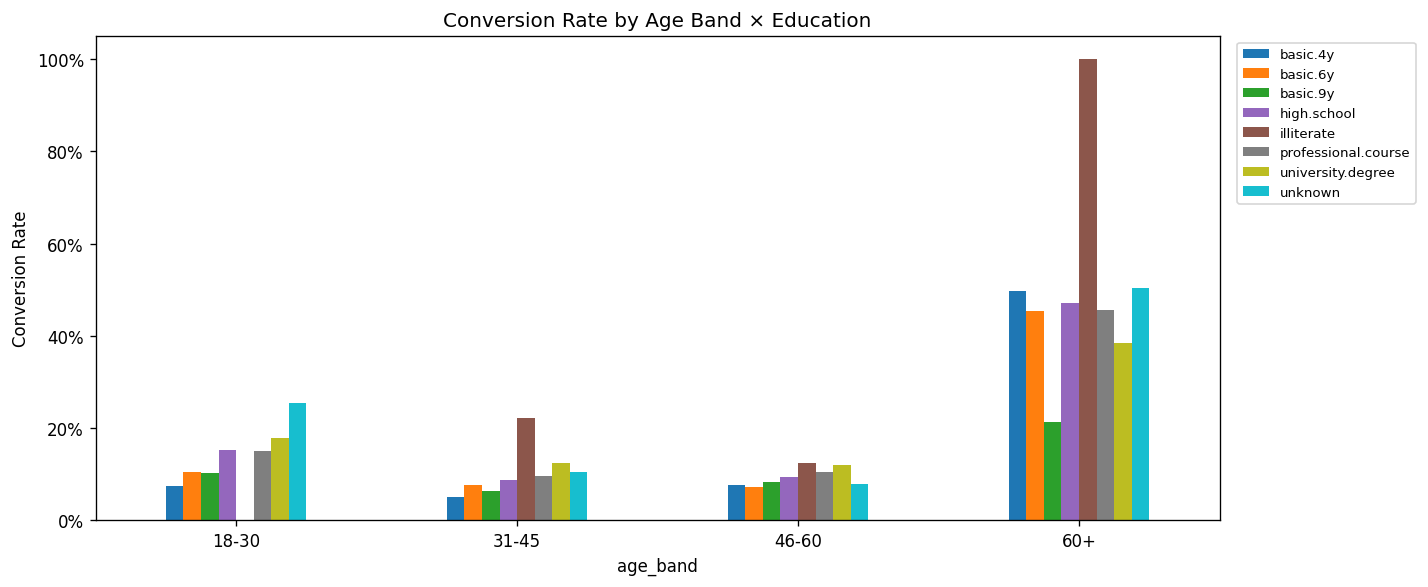

In [9]:
df["age_band"] = pd.cut(df["age"], bins=[17, 30, 45, 60, 100],
                         labels=["18-30", "31-45", "46-60", "60+"])

seg = df.groupby(["age_band", "education"])["y"].apply(
    lambda x: (x == "yes").mean()
).unstack()

seg.plot(kind="bar", figsize=(12, 5), colormap="tab10")
plt.title("Conversion Rate by Age Band × Education")
plt.ylabel("Conversion Rate")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation Matrix (Numeric Features)

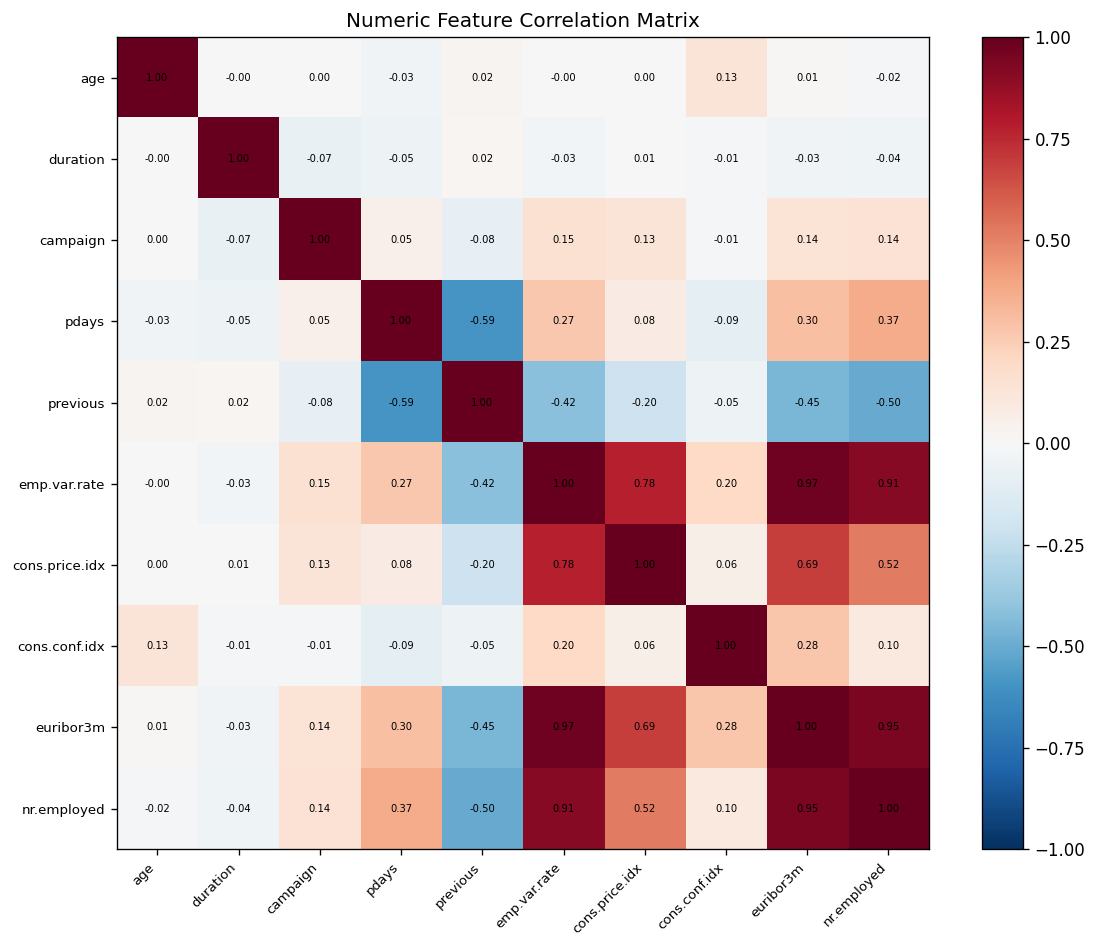

In [10]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title("Numeric Feature Correlation Matrix")

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

## 7. Key Findings Summary

In [11]:
total = len(df)
yes_rate = (df["y"] == "yes").mean()

top_job = df.groupby("job")["y"].apply(lambda x: (x=="yes").mean()).idxmax()
top_edu = df.groupby("education")["y"].apply(lambda x: (x=="yes").mean()).idxmax()
top_month = df.groupby("month")["y"].apply(lambda x: (x=="yes").mean()).idxmax()

print(f"Dataset: {total:,} records")
print(f"Overall conversion: {yes_rate:.1%}")
print(f"Class imbalance: {(1-yes_rate)/yes_rate:.1f}x more 'no' than 'yes'")
print(f"Top converting job: {top_job}")
print(f"Top converting education: {top_edu}")
print(f"Best campaign month: {top_month}")
print()
print("Bandit design implications:")
print("  - High class imbalance → reward signals sparse; Thompson Sampling handles priors well")
print("  - Education + age are strong segmentation signals → use as context features")
print("  - Socioeconomic indicators (euribor3m, emp.var.rate) correlate → include in features")

Dataset: 41,188 records
Overall conversion: 11.3%
Class imbalance: 7.9x more 'no' than 'yes'
Top converting job: student
Top converting education: illiterate
Best campaign month: mar

Bandit design implications:
  - High class imbalance → reward signals sparse; Thompson Sampling handles priors well
  - Education + age are strong segmentation signals → use as context features
  - Socioeconomic indicators (euribor3m, emp.var.rate) correlate → include in features
